# Titanic Survival Prediction

> Predicting passenger survival using machine learning.

## 1- Introduction
The sinking of the Titanic is one of the most well-known maritime disasters in history. This project uses the Titanic passenger dataset to build a machine learning model capable of predicting whether a passenger survived the disaster based on available passenger information.

The target variable is Survived, making this a binary classification problem, where the model predicts one of two possible outcomes: survived or did not survive.

## 2- Problem defination
In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).


## 3. Dataset Overview

The dataset contains information about passengers aboard the Titanic. Each row represents one passenger, while each column contains a specific characteristic or attribute of that passenger.

The dataset contains **891 passengers** and **15 columns**, including the target variable `survived`.

### Feature Description

| Column | Description | Type |
|:---|:---|:---:|
| `survived` | Indicates whether the passenger survived. `0` = No, `1` = Yes. | Binary |
| `pclass` | Passenger's ticket class: `1` = First, `2` = Second, `3` = Third. | Categorical / Ordinal |
| `sex` | Passenger's sex. | Categorical |
| `age` | Passenger's age in years. | Numerical |
| `sibsp` | Number of siblings or spouses traveling with the passenger. | Numerical |
| `parch` | Number of parents or children traveling with the passenger. | Numerical |
| `fare` | Passenger's ticket fare. | Numerical |
| `embarked` | Port where the passenger boarded: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton. | Categorical |
| `class` | Passenger class represented as text: First, Second, or Third. | Categorical |
| `who` | Passenger category: man, woman, or child. | Categorical |
| `adult_male` | Indicates whether the passenger was an adult male. | Boolean |
| `deck` | The deck on which the passenger's cabin was located. | Categorical |
| `embark_town` | Name of the town where the passenger boarded. | Categorical |
| `alive` | Survival status represented as `yes` or `no`. | Categorical |
| `alone` | Indicates whether the passenger was traveling alone. | Boolean |

### Target Variable

The target variable for this project is **`survived`**.

It is a binary variable:

- `0` → Passenger did not survive
- `1` → Passenger survived

Therefore, this project is a **Binary Classification** problem.

In [1]:
# importing necessary Libaries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(1917)

In [2]:
## Load Dataset
Titanic_df=sns.load_dataset("titanic")

## 4-EDA

In [3]:
Titanic_df.shape

(891, 15)

In [4]:
Titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
Titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
"""
checking the number of unique values in each colum to distingush
between categorical and Continous values
"""
Titanic_df.nunique(dropna=True)

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [7]:
Titanic_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# checking Null values in each colum
Titanic_df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

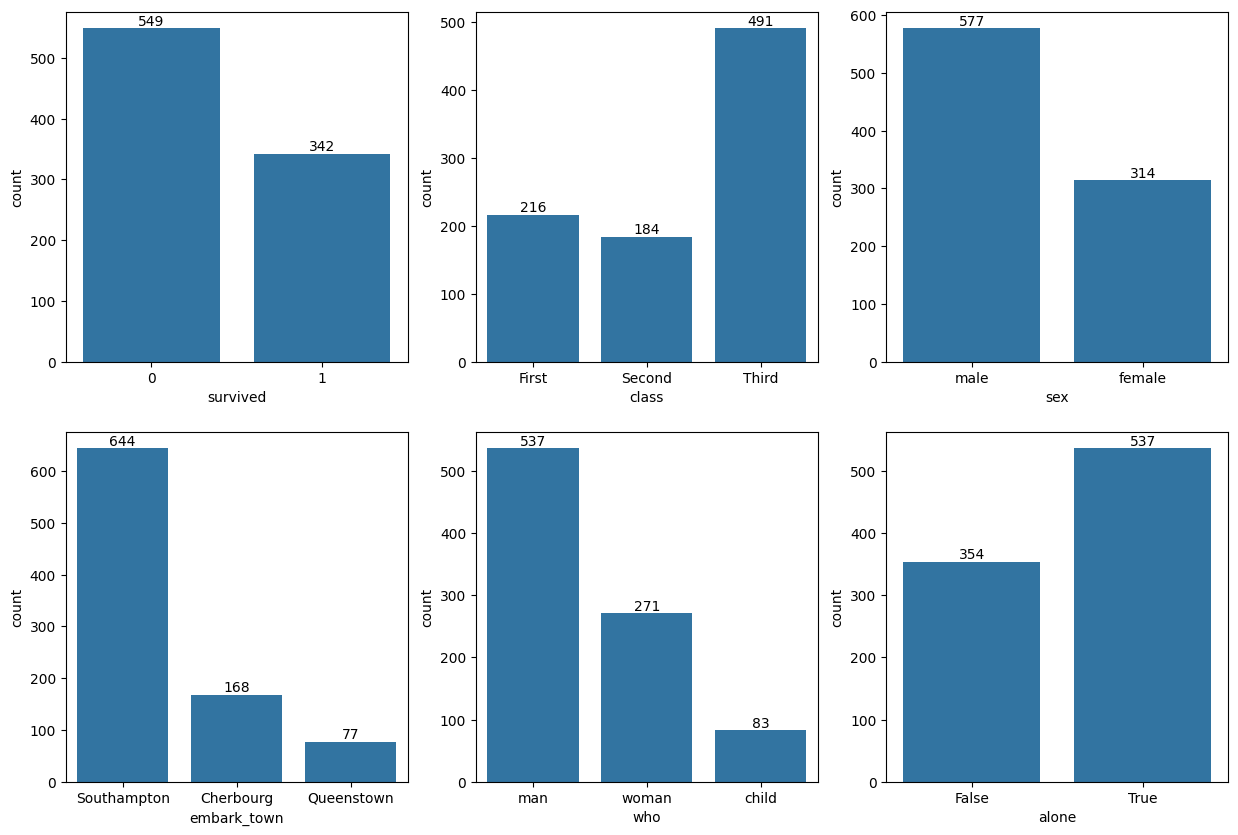

In [9]:
# Visualize the Categorical Columns
Categorical_Columns=[["survived","class","sex"],["embark_town","who","alone"]]
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(15,10))
for i in range(0,2):
    for j in range(0,3):
        ax=sns.countplot(data=Titanic_df,x=Categorical_Columns[i][j],ax=axes[i][j])
        for container in ax.containers:
            ax.bar_label(container)       
plt.show()        

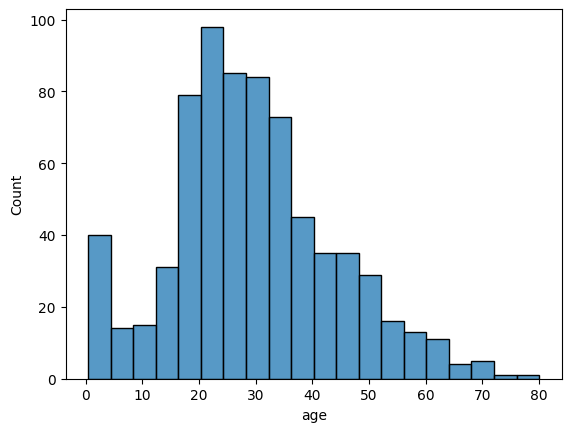

In [10]:
#  the distribution of the age
sns.histplot(data=Titanic_df,x="age")
plt.show()

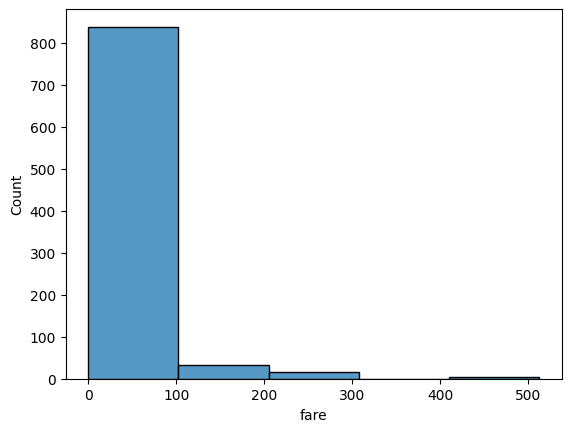

In [11]:
#  the distribution of the fare
sns.histplot(data=Titanic_df,x="fare",bins=5)
plt.show()

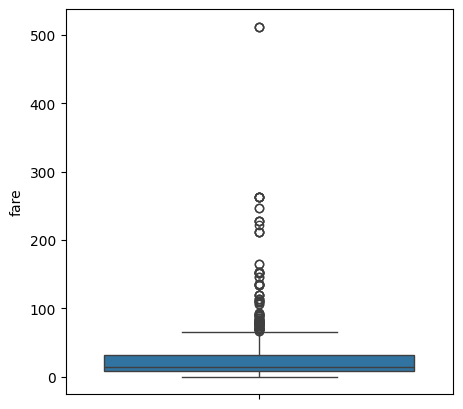

In [12]:
# checking The outliers in the fare
fig,ax=plt.subplots(figsize=(5,5))
sns.boxplot(data=Titanic_df,y="fare",ax=ax)
plt.show()

<Axes: ylabel='fare'>

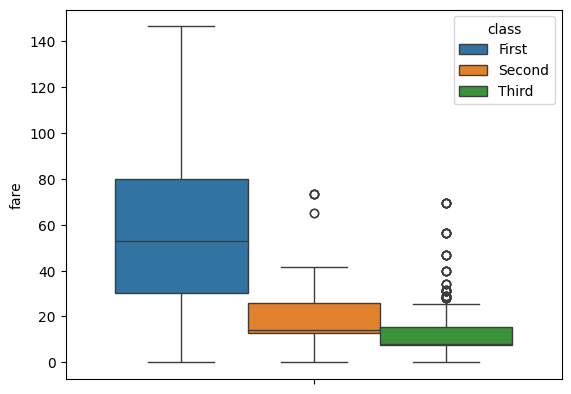

In [13]:
sns.boxplot(data=Titanic_df.iloc[Titanic_df["fare"]<150],hue="class",y="fare")

### Obervation
The Higher the class the higher the fare you should pay

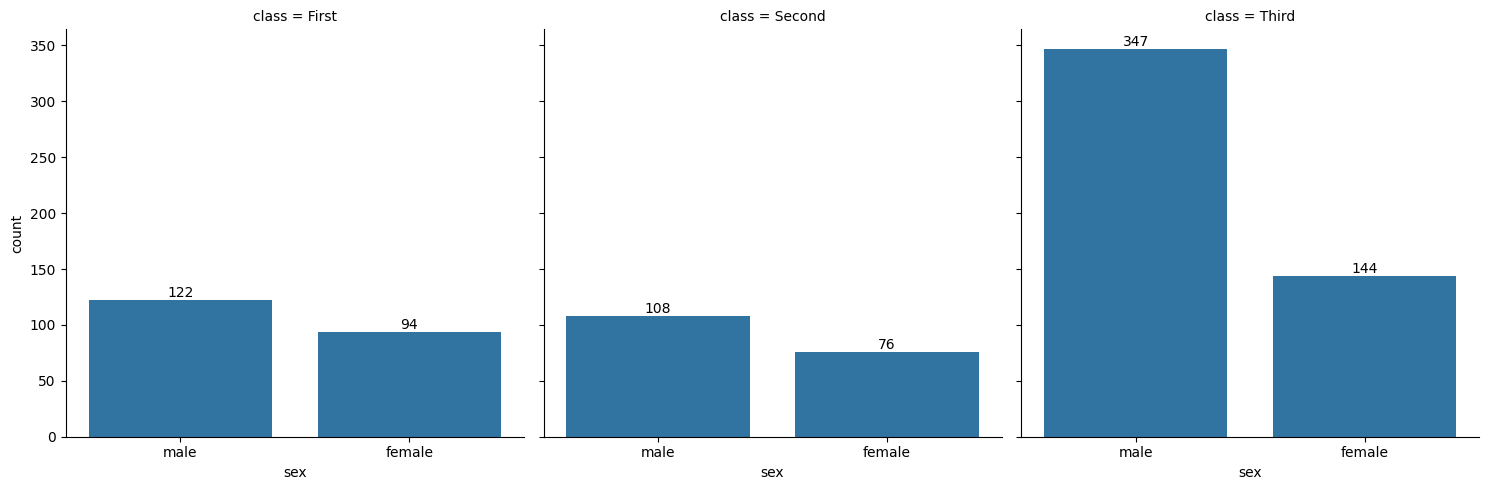

In [14]:
# the number of men and womens in each class
g=sns.catplot(data=Titanic_df,col="class",x="sex",kind="count")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
plt.show()

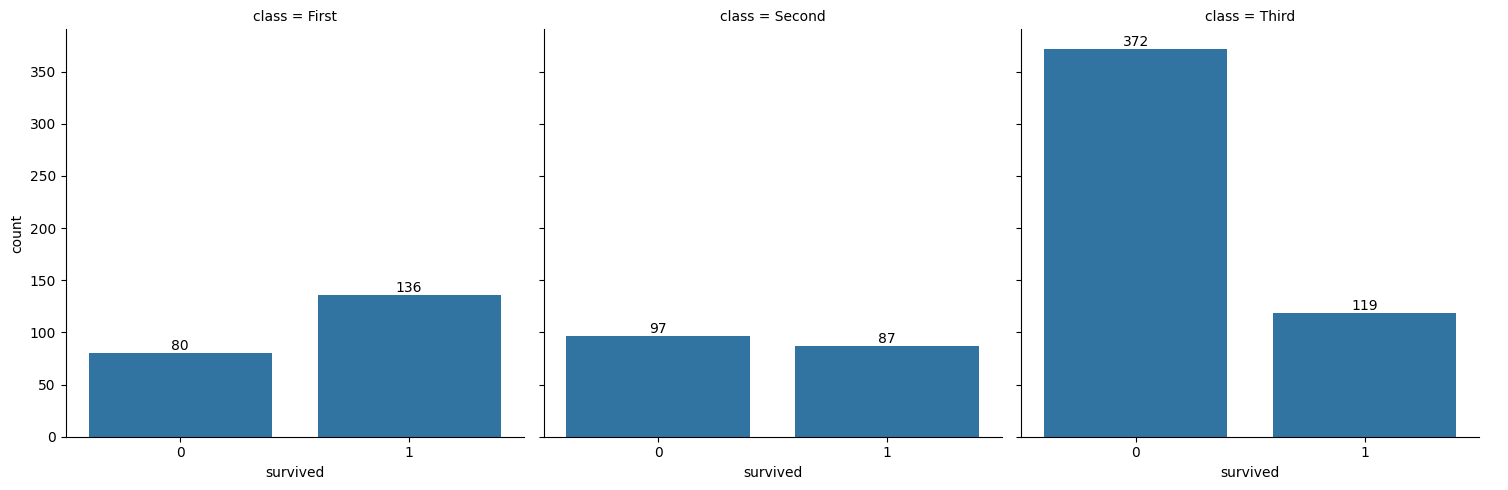

In [15]:
# See the number pf survivals in each class
g=sns.catplot(data=Titanic_df,col="class",x="survived",kind="count")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
plt.show()

In [16]:
# see the precentage of survivals in each class
Titanic_df.groupby("class").survived.value_counts(normalize=True)

class   survived
First   1           0.629630
        0           0.370370
Second  0           0.527174
        1           0.472826
Third   0           0.757637
        1           0.242363
Name: proportion, dtype: float64

>  It is very obivous that bigger percentage of  first 2 classes survived  comapred to the Third class

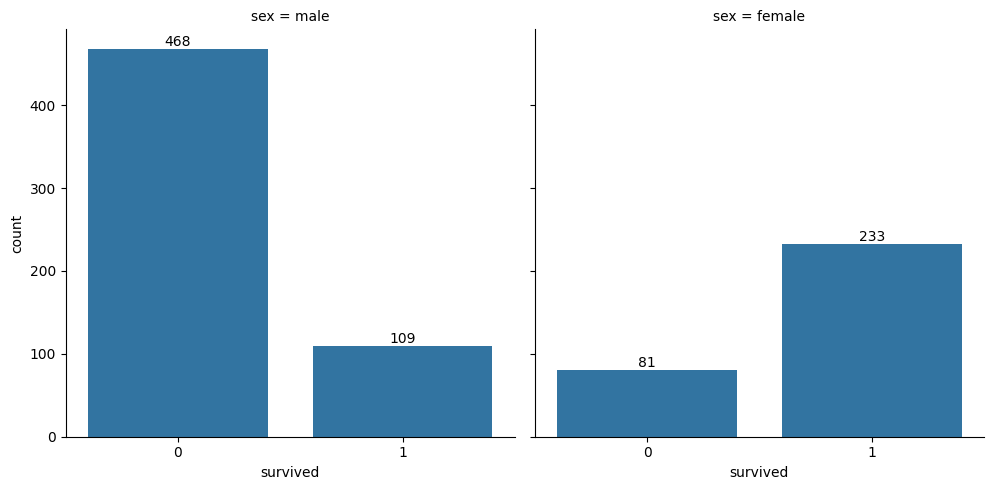

In [17]:
# See the number pf survivals in each sex
g=sns.catplot(data=Titanic_df,col="sex",x="survived",kind="count")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
plt.show()

In [18]:
# see the precentage of survivals in each class
Titanic_df.groupby("sex").survived.value_counts(normalize=True)

sex     survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

### Observation
Most of womens survives.But men were unlucky

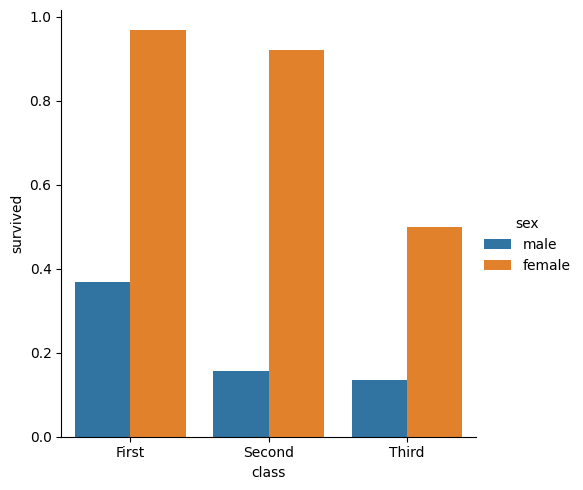

In [19]:
# Plots the survival probability (0.0 to 1.0) instead of raw passenger count

sns.catplot(
    data=Titanic_df, 
    x="class", 
    y="survived", 
    hue="sex", 
    kind="bar", 
    errorbar=None
)
plt.show()

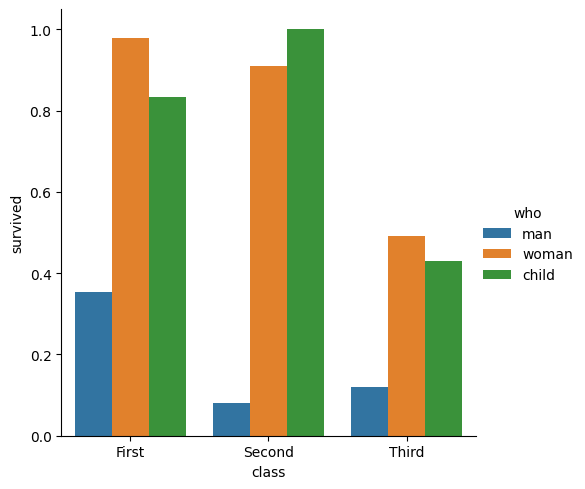

In [20]:
sns.catplot(data=Titanic_df,x="class",y="survived",kind="bar",hue="who",errorbar=None)

### Observation
We see that childs and women have the highest chances to survive

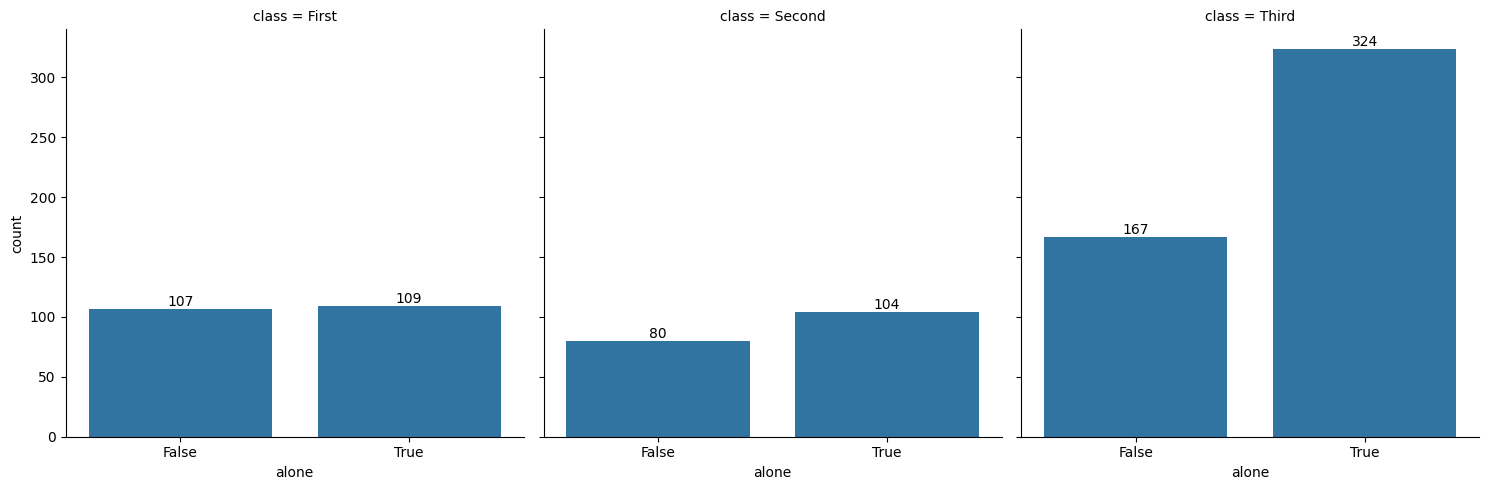

In [21]:
# visualize The Total number of people who went alone in titanic in each class
g=sns.catplot(data=Titanic_df,col="class",x="alone",kind="count")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

In [22]:
Titanic_df.groupby("class").alone.value_counts(normalize=True)

class   alone
First   True     0.504630
        False    0.495370
Second  True     0.565217
        False    0.434783
Third   True     0.659878
        False    0.340122
Name: proportion, dtype: float64

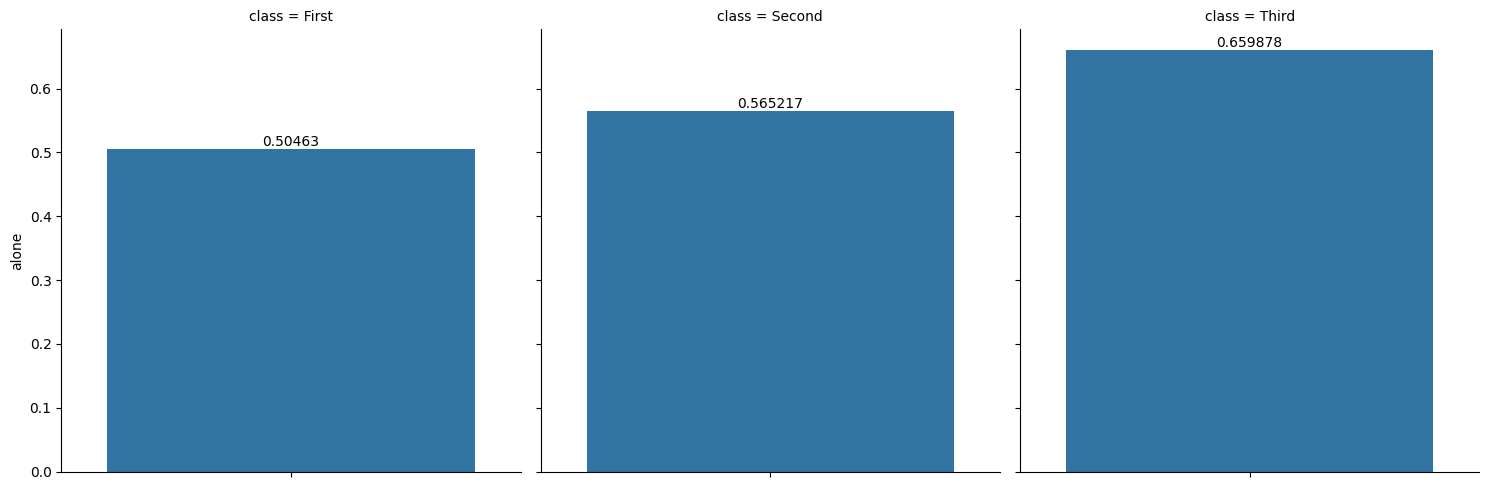

In [23]:
# visualize The precantage of people who went alone in titanic in each class
g=sns.catplot(data=Titanic_df,col="class",y="alone",kind="bar",errorbar=None)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

### Observation
The higher the class the higher percentage of people tends to go with thier familes

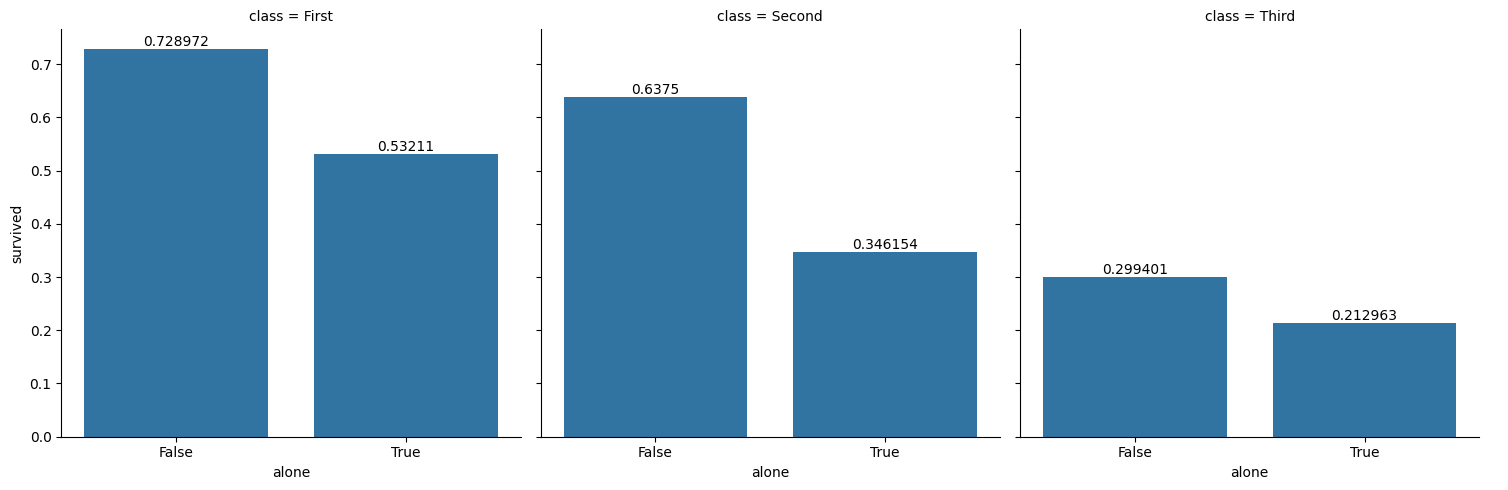

In [24]:
# How Travling alone will afftect your chances to suvive ?
g=sns.catplot(data=Titanic_df,col="class",x="alone",y="survived",kind="bar",errorbar=None)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

### Observation
In each class , The person who is travlling alone has a lower chances to survive than if he was with someone

In [25]:
Titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: >

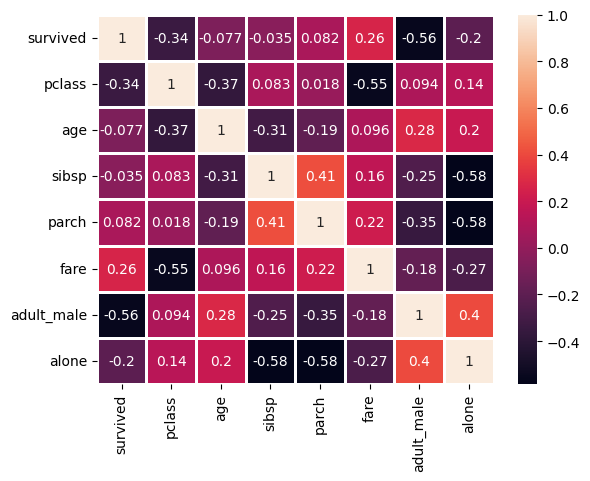

In [26]:
## plottoing the correlation between Features
sns.heatmap(Titanic_df.corr(numeric_only=True),annot=True,linewidths=2)

### Observation
It is very obvious from the correlation that travlling in higher class , being a women or a child and travlling with someone will increase your chances to survive

## 3- Data Preprocessing

In [27]:
Titanic_df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Observation
- Most of `deck` colum is null so there is no need for this colum, and if you think about it How the deck will afftect your chances to survive ?! so we are going to remove it anyway
-  The `embarked town`is the same as `embarked` Column so we can drop The last one and fill the nulls with the Mode
- The `age` colum we can fil it with median
- The `Alive` colum is the same as Survive some we should delete it to avoid data leakage


In [28]:
def Preproccesing(df):
    df_new=df.drop(["deck","class","embark_town","alive"],axis=1)
    median_age=df_new.age.median()
    df_new.age=df_new.age.fillna(median_age)
    Mode_embarked=df_new.embarked.mode().iloc[0]
    df_new.embarked=df_new.embarked.fillna(Mode_embarked)
    df_new.adult_male=df_new.adult_male.astype("int32")
    df_new.alone=df_new.alone.astype("int32")
    return df_new

In [29]:
titanic_df=Preproccesing(Titanic_df)

In [30]:
titanic_df.isna().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
who           0
adult_male    0
alone         0
dtype: int64

In [31]:
y=titanic_df["survived"]
x=titanic_df.drop("survived",axis=1)


In [32]:
cat_columns=["sex","embarked","who"]
numeric_colums=["pclass","age",	"sibsp"	,"parch","fare"]
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(
    transformers=[
        ("numeric",StandardScaler(),numeric_colums),
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_columns)
    ]
        ,remainder="passthrough"
    )


### 4- Splitting Data


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,shuffle=True,stratify=y)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,random_state=42,shuffle=True,stratify=y_test)
print("X_train Size :",x_train.shape)
print("X_Val Size :",x_val.shape)
print("X_test Size :",x_test.shape)
print("y_train Size :",y_train.shape)
print("y_Val Size :",y_val.shape)
print("y_test Size :",y_test.shape)


X_train Size : (623, 10)
X_Val Size : (134, 10)
X_test Size : (134, 10)
y_train Size : (623,)
y_Val Size : (134,)
y_test Size : (134,)


In [34]:
x_train_transformed=transformer.fit_transform(x_train)

## Traning a ML Model

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve,roc_auc_score
# Define a function to meausre our model predictions

def Model_Evaluation(y_true,y_preds):
    accuracy=accuracy_score(y_true,y_preds)
    f1=f1_score(y_true,y_preds)
    recall=recall_score(y_true,y_preds)
    precision=precision_score(y_true,y_preds)
    print(f"Accuracy Score :{accuracy:.3f} ")
    print(f"F1 Score       :{f1:.3f} ")
    print(f"Recall score   :{recall_score(y_true,y_preds):.3f} ")
    print(f"precision Score:{precision:.3f} ")
    ConfusionMatrixDisplay.from_predictions(y_true,y_preds)
    return {
        "accuracy":accuracy,
        "f1":f1,
        "recall":recall,
        "precision":precision    
    }
    
    
    

Accuracy Score :0.825 
F1 Score       :0.761 
Recall score   :0.728 
precision Score:0.798 


{'accuracy': 0.8250401284109149,
 'f1': 0.7614879649890591,
 'recall': 0.7280334728033473,
 'precision': 0.7981651376146789}

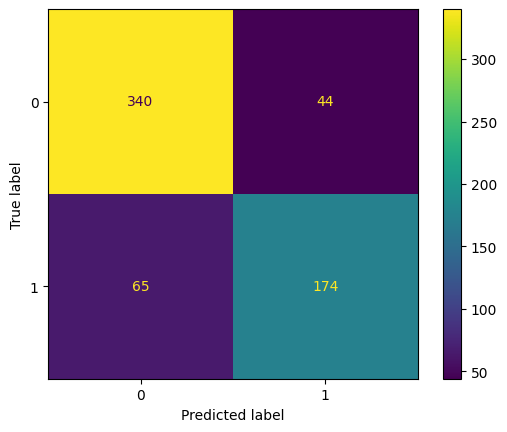

In [36]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(random_state=1917,max_iter=1000)
log_reg.fit(x_train_transformed,y_train)
log_reg_train_preds=log_reg.predict(x_train_transformed)
Model_Evaluation(y_train,log_reg_train_preds)

Accuracy Score :0.873 
F1 Score       :0.838 
Recall score   :0.846 
precision Score:0.830 


{'accuracy': 0.8731343283582089,
 'f1': 0.8380952380952381,
 'recall': 0.8461538461538461,
 'precision': 0.8301886792452831}

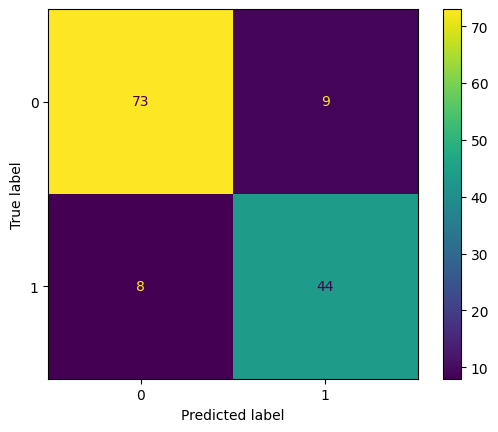

In [37]:
log_reg_val_predict=log_reg.predict(transformer.transform(x_val))
Model_Evaluation(y_val,log_reg_val_predict)

In [38]:
from sklearn.model_selection import GridSearchCV
log_reg_param_grid={"C":[0.1,0.001,0.0001,1,10,100],
                    "solver":["lbfgs", "liblinear"],
                    "class_weight":[None,"balanced"]}
log_reg_grid_search=GridSearchCV(LogisticRegression(random_state=1917,max_iter=10000),log_reg_param_grid,
            cv=5,scoring="accuracy",n_jobs=-1)
log_reg_grid_search.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...om_state=1917)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.001, ...], 'class_weight': [None, 'balanced'], 'solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [39]:
log_reg_grid_search.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1917
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy Score :0.820 
F1 Score       :0.754 
Recall score   :0.720 
precision Score:0.793 


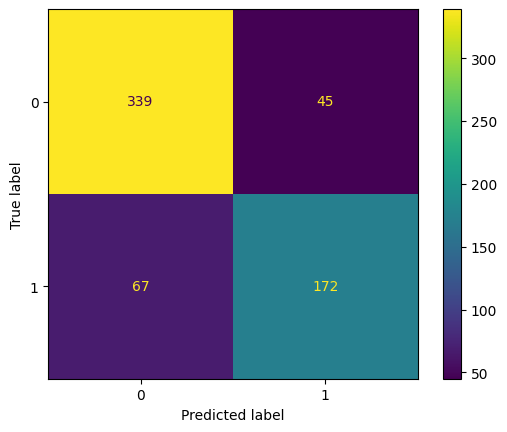

In [40]:
# Re fetting our model on best params
log_reg=LogisticRegression(random_state=1917,max_iter=100000,C=0.1,solver="liblinear")
log_reg.fit(x_train_transformed,y_train)
log_reg_train_preds=log_reg.predict(x_train_transformed)
log_reg_train_results=Model_Evaluation(y_train,log_reg_train_preds)

Accuracy Score :0.858 
F1 Score       :0.812 
Recall score   :0.788 
precision Score:0.837 


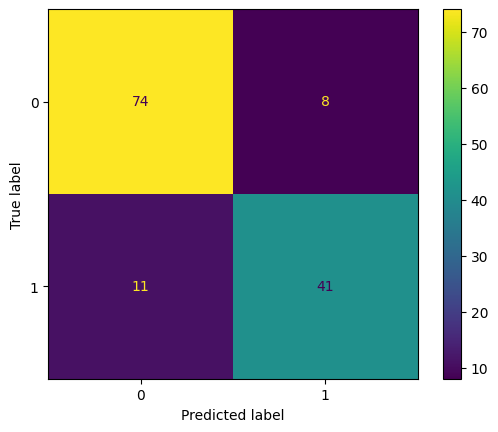

In [41]:
log_reg_val_predict=log_reg.predict(transformer.transform(x_val))
log_reg_val_results=Model_Evaluation(y_val,log_reg_val_predict)

### Logistic Regression Evaluation
the Overall preformace is accpetable but not Great

Accuracy Score :0.979 
F1 Score       :0.973 
Recall score   :0.962 
precision Score:0.983 


{'accuracy': 0.9791332263242376,
 'f1': 0.9725158562367865,
 'recall': 0.9623430962343096,
 'precision': 0.9829059829059829}

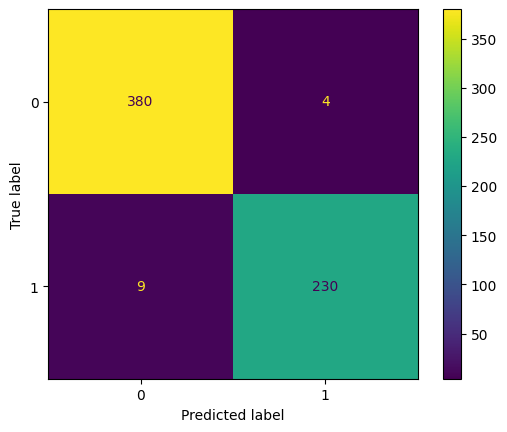

In [42]:
# lets train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
random_forest=RandomForestClassifier(random_state=1917)
random_forest.fit(x_train_transformed,y_train)
random_forest_train_preds=random_forest.predict(x_train_transformed)
Model_Evaluation(y_train,random_forest_train_preds)



Accuracy Score :0.858 
F1 Score       :0.812 
Recall score   :0.788 
precision Score:0.837 


{'accuracy': 0.8582089552238806,
 'f1': 0.8118811881188119,
 'recall': 0.7884615384615384,
 'precision': 0.8367346938775511}

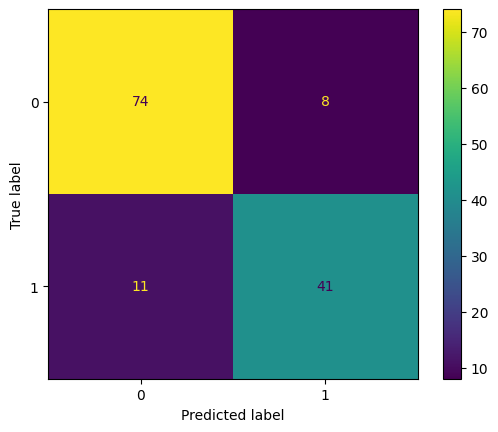

In [43]:
random_forest_val_preds=random_forest.predict(transformer.transform(x_val))
Model_Evaluation(y_val,random_forest_val_preds)

In [44]:
Random_Forest_param_grid={"n_estimators":[100, 200, 500, 1000],
                         "max_depth":[None, 5, 10, 20, 30],
                         "min_samples_split":[2, 5, 10, 20],
                         "min_samples_leaf":[1, 2, 4, 8],
                         "bootstrap":[True,False]}
Radom_Forest_Grid_Search=GridSearchCV(RandomForestClassifier(random_state=1917)
                                      ,Random_Forest_param_grid,cv=3
                                      ,scoring="accuracy",n_jobs=-1
                                     )

Radom_Forest_Grid_Search.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...om_state=1917)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [45]:
Radom_Forest_Grid_Search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

Accuracy Score :0.928 
F1 Score       :0.903 
Recall score   :0.874 
precision Score:0.933 


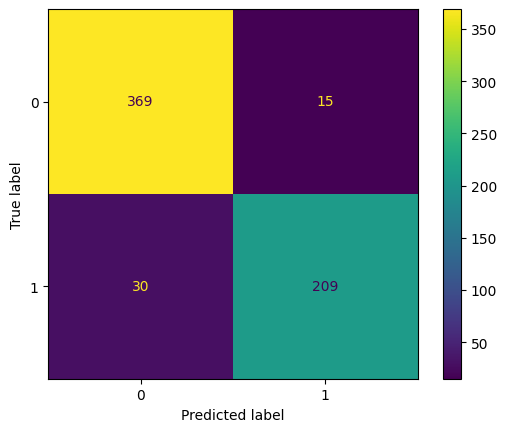

In [46]:
# Refitting Our Model On GridSearchBestParams
random_forest=RandomForestClassifier(random_state=1917,n_estimators=200
                                     ,bootstrap=False,min_samples_split=5
                                     ,min_samples_leaf=2)
random_forest.fit(x_train_transformed,y_train)
random_forest_train_preds=random_forest.predict(x_train_transformed)
Random_Forest_Train_Results=Model_Evaluation(y_train,random_forest_train_preds)


Accuracy Score :0.873 
F1 Score       :0.828 
Recall score   :0.788 
precision Score:0.872 


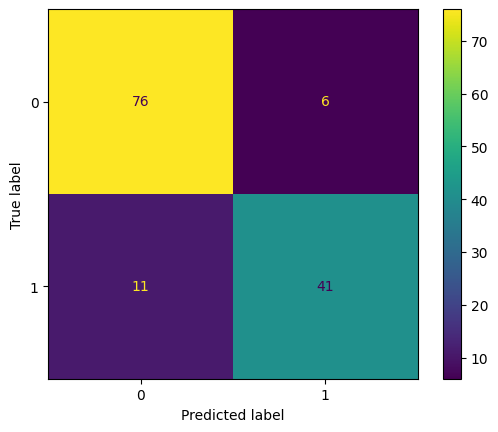

In [47]:
random_forest_val_preds=random_forest.predict(transformer.transform(x_val))
Random_Forest_Val_Results=Model_Evaluation(y_val,random_forest_val_preds)

Accuracy Score :0.846 
F1 Score       :0.784 
Recall score   :0.728 
precision Score:0.849 


{'accuracy': 0.8459069020866774,
 'f1': 0.7837837837837838,
 'recall': 0.7280334728033473,
 'precision': 0.848780487804878}

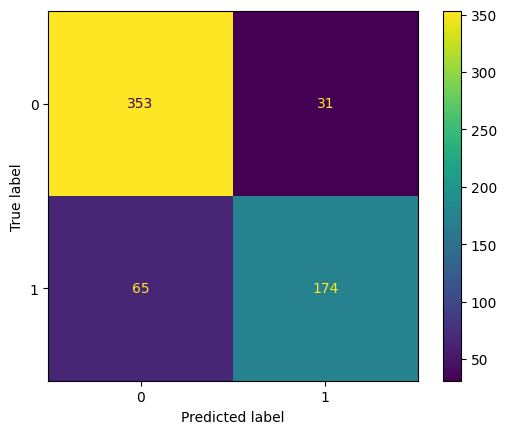

In [48]:
from sklearn.svm import SVC
svc_clf=SVC()
svc_clf.fit(x_train_transformed,y_train)
y_train_preds=svc_clf.predict(x_train_transformed)
Model_Evaluation(y_train,y_train_preds)

In [49]:
svc_param_grid={
    "C": [50, 25, 15, 10, 20],
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "gamma": ["scale", "auto", 0.2, 0.1, 0.5,0.7]
}
svc_grid_search=GridSearchCV(SVC(),svc_param_grid,cv=3,n_jobs=-1,scoring="accuracy")
svc_grid_search.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [50, 25, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [50]:
svc_grid_search.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Accuracy Score :0.865 
F1 Score       :0.812 
Recall score   :0.757 
precision Score:0.874 


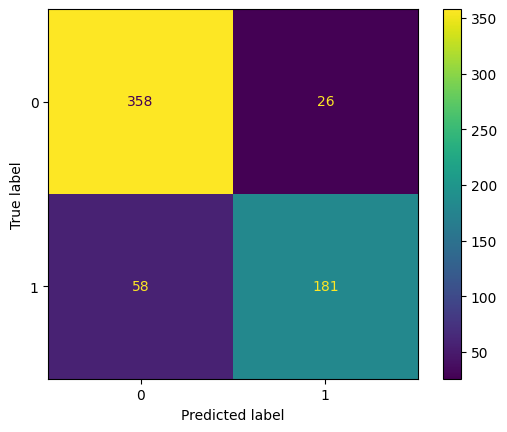

In [51]:
# Re fitting The SVC on the best params
svc_clf=SVC(C=10,gamma=0.1,kernel="rbf",degree=3)
svc_clf.fit(x_train_transformed,y_train)
y_train_preds=svc_clf.predict(x_train_transformed)
SVC_Train_Results=Model_Evaluation(y_train,y_train_preds)

Accuracy Score :0.821 
F1 Score       :0.755 
Recall score   :0.712 
precision Score:0.804 


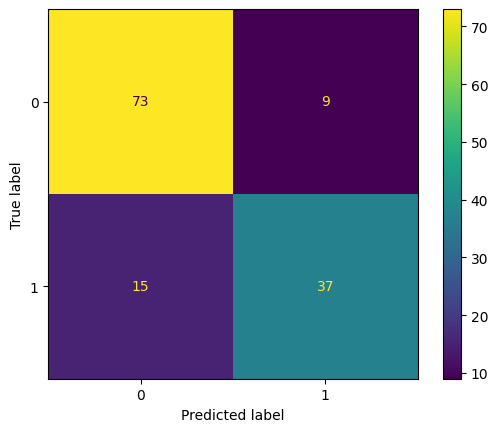

In [52]:
y_val_preds=svc_clf.predict(transformer.transform(x_val))
SVC_Val_Results=Model_Evaluation(y_val,y_val_preds)

In [53]:
from sklearn.neighbors import KNeighborsClassifier
KNeighbors_params_grid={"n_neighbors":[21,20,19,17,18]}
KNeighbors_Grid_search_clf=GridSearchCV(KNeighborsClassifier(),KNeighbors_params_grid,cv=3,n_jobs=-1,scoring="accuracy")
KNeighbors_Grid_search_clf.fit(x_train_transformed,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [21, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

Accuracy Score :0.830 
F1 Score       :0.763 
Recall score   :0.715 
precision Score:0.818 


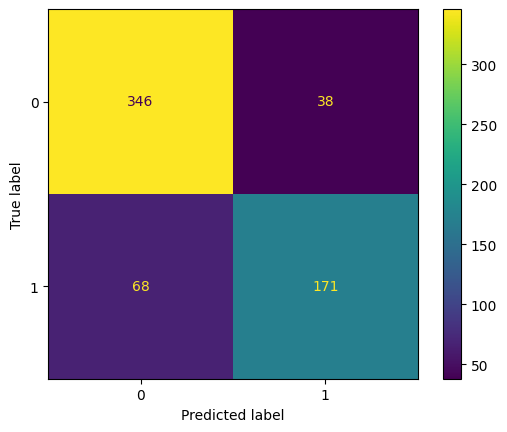

In [54]:
KNeighbors_clf=KNeighborsClassifier(n_neighbors=19)
KNeighbors_clf.fit(x_train_transformed,y_train)
y_train_preds=KNeighbors_clf.predict(x_train_transformed)
KNeighbors_Train_Results=Model_Evaluation(y_train,y_train_preds)

Accuracy Score :0.836 
F1 Score       :0.776 
Recall score   :0.731 
precision Score:0.826 


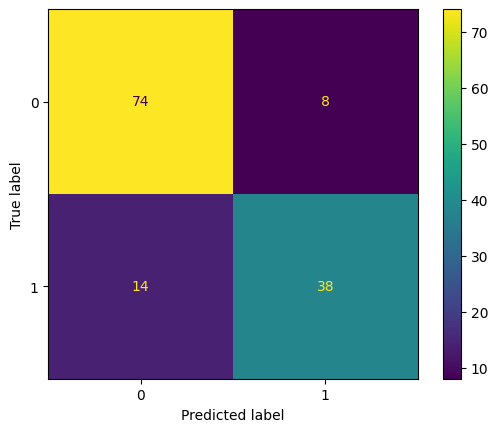

In [55]:
y_val_preds=KNeighbors_clf.predict(transformer.transform(x_val))
KNeighbors_Val_Results=Model_Evaluation(y_val,y_val_preds)

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
XGBClassifier_param_grid={
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7], 
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10]
}
XGBClassifier_RandomizedSearchCV=RandomizedSearchCV(XGBClassifier(random_state=1917)
                                      ,XGBClassifier_param_grid,cv=3
                                      ,scoring="accuracy",n_jobs=-1,n_iter=10000
                                     )

XGBClassifier_RandomizedSearchCV.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [57]:
print(XGBClassifier_RandomizedSearchCV.best_params_)

{'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.7}


Accuracy Score :0.913 
F1 Score       :0.882 
Recall score   :0.845 
precision Score:0.922 


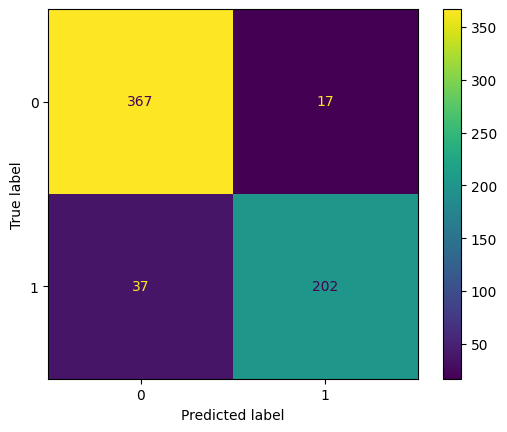

In [58]:
# Refitting Our Model On GridSearchBestParams
XGB_clf=XGBClassifier(subsample= 1.0, reg_lambda= 1, reg_alpha= 0, n_estimators= 200, min_child_weight= 1, max_depth= 8, learning_rate= 0.1, gamma= 0.5, colsample_bytree= 0.8)
XGB_clf.fit(x_train_transformed,y_train)
XGB_clf_train_preds=XGB_clf.predict(x_train_transformed)
XGB_clf_Train_Results=Model_Evaluation(y_train,XGB_clf_train_preds)


Accuracy Score :0.858 
F1 Score       :0.804 
Recall score   :0.750 
precision Score:0.867 


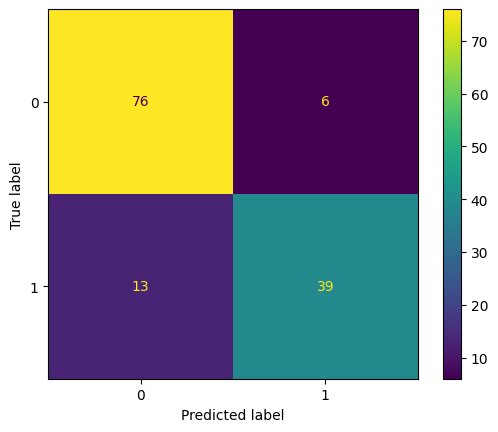

In [59]:
XGB_clf_val_preds=XGB_clf.predict(transformer.transform(x_val))
XGB_clf_Val_Results=Model_Evaluation(y_val,XGB_clf_val_preds)

Accuracy Score :0.918 
F1 Score       :0.889 
Recall score   :0.858 
precision Score:0.923 


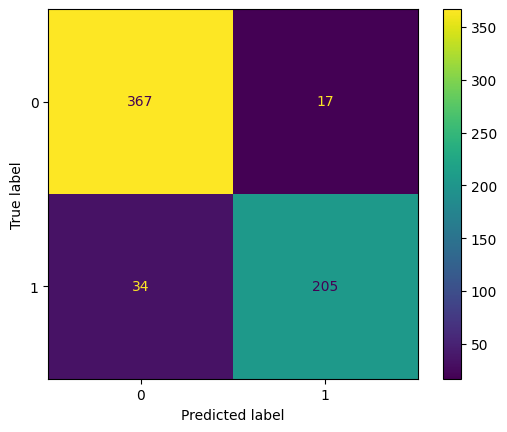

In [60]:
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
estimators=[('XGB',XGB_clf ), ("RandomForest",random_forest)],
voting='soft')
voting_clf.fit(x_train_transformed, y_train)
voting_clf_train_preds=voting_clf.predict(x_train_transformed)
voting_clf_Train_Results=Model_Evaluation(y_train,voting_clf_train_preds)

Accuracy Score :0.873 
F1 Score       :0.825 
Recall score   :0.769 
precision Score:0.889 


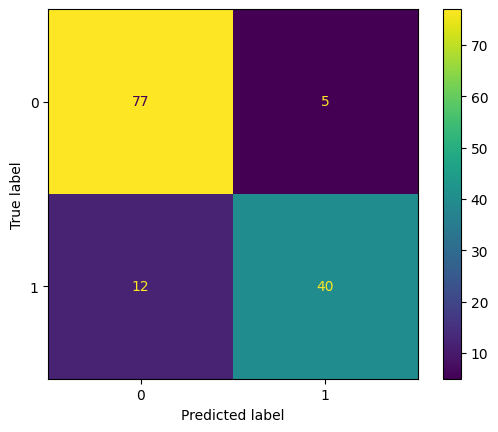

In [61]:
voting_clf_val_preds=voting_clf.predict(transformer.transform(x_val))
voting_clf_Val_Results=Model_Evaluation(y_val,voting_clf_val_preds)

In [62]:
Models_Results=pd.DataFrame({"LogisticRegression":[log_reg_train_results,log_reg_val_results],
                           "SVC":[SVC_Val_Results,SVC_Val_Results],
                            "RandomForest":[Random_Forest_Train_Results,Random_Forest_Val_Results],
                            "KNeighbors":[KNeighbors_Train_Results,KNeighbors_Val_Results],
                            "XGB":[XGB_clf_Train_Results,XGB_clf_Val_Results],
                             "Voting Classifier":[voting_clf_Train_Results,voting_clf_Val_Results]
                           })

In [63]:
accuracy_results = []

for model, values in Models_Results.items():
    accuracy_results.append({
        "Model": model,
        "Train": values.iloc[0]["accuracy"],
        "Validation": values.iloc[1]["accuracy"]
    })

accuracy_df = pd.DataFrame(accuracy_results)

print(accuracy_df)

                Model     Train  Validation
0  LogisticRegression  0.820225    0.858209
1                 SVC  0.820896    0.820896
2        RandomForest  0.927769    0.873134
3          KNeighbors  0.829856    0.835821
4                 XGB  0.913323    0.858209
5   Voting Classifier  0.918138    0.873134


In [ ]:
# Visualizing the accuracy Between Models
accuracy_df.plot(
    x="Model",
    y=["Train", "Validation"],
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Train vs Validation Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Test Our Models

In [ ]:
random_forest_test_preds=random_forest.predict(transformer.transform(x_test))
Random_Forest_test_Results=Model_Evaluation(y_test,random_forest_test_preds)

In [ ]:
voting_clf_test_preds=voting_clf.predict(transformer.transform(x_test))
voting_clf_test_Results=Model_Evaluation(y_test,voting_clf_test_preds)

In [ ]:
XGB_clf_test_preds=XGB_clf.predict(transformer.transform(x_test))
XGB_clf_test_Results=Model_Evaluation(y_test,XGB_clf_test_preds)

### Observation 
RandomForest Is the Best Model

In [ ]:
## Combine the Valdation set and training set togther to test Our final Model
X_train_final=np.concatenate([x_train_transformed,transformer.transform(x_val)])
y_train_final=np.concatenate([y_train,y_val])
random_forest=RandomForestClassifier(random_state=1917,n_estimators=200
                                     ,bootstrap=False,min_samples_split=5
                                     ,min_samples_leaf=2)
random_forest.fit(X_train_final,y_train_final)


In [ ]:
random_forest_test_preds=random_forest.predict(transformer.transform(x_test))
Random_Forest_test_Results=Model_Evaluation(y_test,random_forest_test_preds)